In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

%matplotlib inline

path = (r"C:\Users\utkar\OneDrive\Desktop\projrcts data set\airbnb.csv")
df = pd.read_csv(path)
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,19-10-2018,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,21-05-2019,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,05-07-2019,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,19-11-2018,0.10,1,0


In [23]:
# data cleaning
df_cleaned = df.dropna(subset=['name','host_name'])
# converting last_review to date time format
df_cleaned.loc[:,'last_review']  = pd.to_datetime(df_cleaned['last_review'],errors ='coerce',dayfirst = True)
# filling missing values from 'reviews per month' with 0
df_cleaned.loc[:,'reviews_per_month'] = df_cleaned['reviews_per_month'].fillna(0)
# remove listings with price <= 0 or minimum_nights <= 0
df_cleaned = df_cleaned[(df_cleaned['price'] > 0) & (df_cleaned['minimum_nights'] > 0)]

df_cleaned.to_csv('airbnb_cleaned',index=False)


In [27]:
#summary stats
df_cleaned[['price', 'minimum_nights', 'number_of_reviews', 'availability_365']].describe()


,price,minimum_nights,number_of_reviews,availability_365
count,48847.000000,48847.000000,48847.000000,48847.000000
mean,152.774705,7.012365,23.270621,112.799599
std,240.248498,20.021362,44.550647,131.615947
min,10.000000,1.000000,0.000000,0.000000
25%,69.000000,1.000000,1.000000,0.000000
50%,106.000000,3.000000,5.000000,45.000000
75%,175.000000,5.000000,24.000000,227.000000
max,10000.000000,1250.000000,629.000000,365.000000


In [25]:
df_cleaned['room_type'].value_counts()
df_cleaned['neighbourhood_group'].value_counts()


neighbourhood_group
Manhattan        21642
Brooklyn         20080
Queens            5664
Bronx             1088
Staten Island      373
Name: count, dtype: int64

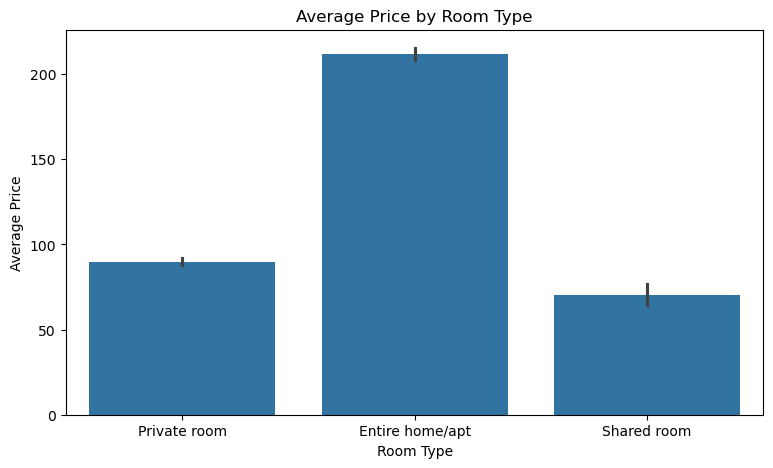

In [30]:
#visualization
# Average price per room type
plt.figure(figsize=(9, 5))
sns.barplot(data=df_cleaned, x='room_type', y='price', estimator=np.mean)
plt.title('Average Price by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Average Price')
plt.show()


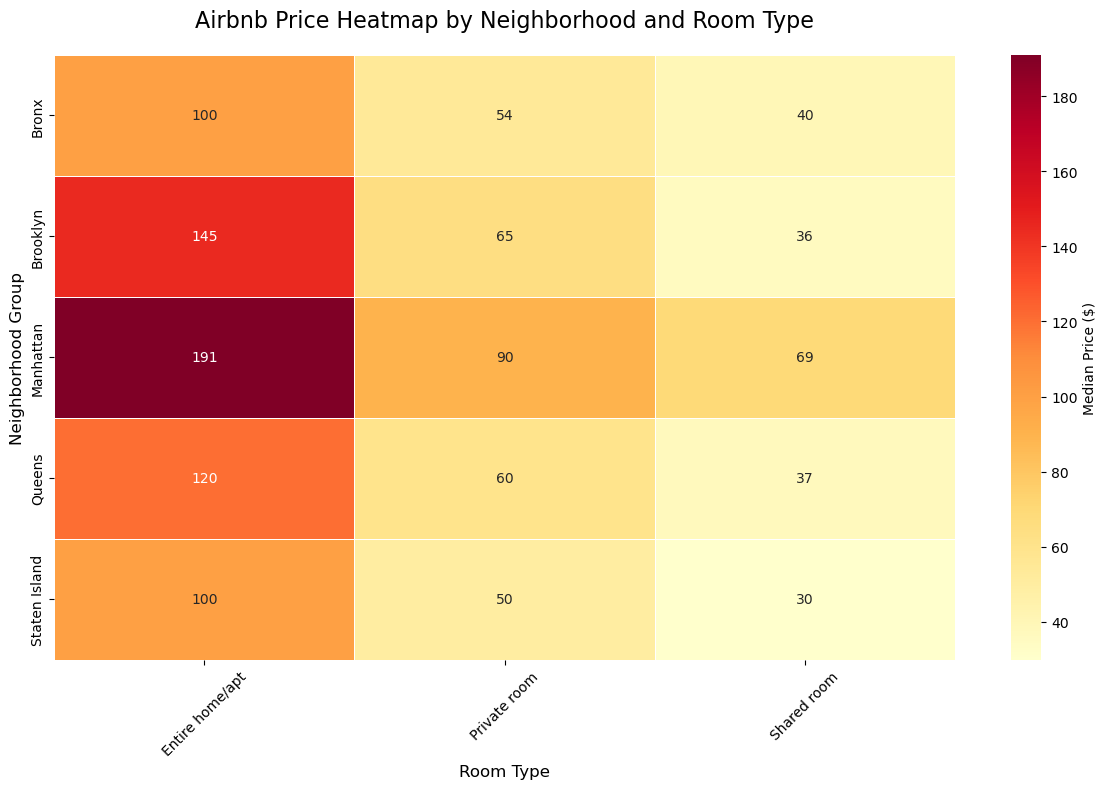

In [38]:
#heatmap
# Create pivot table for heatmap
heatmap_data = df_cleaned.pivot_table(
    values='price',
    index='neighbourhood_group',
    columns='room_type',
    aggfunc='median'
)

plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    annot=True,
    fmt=".0f",
    linewidths=.5,
    cbar_kws={'label': 'Median Price ($)'}
)

plt.title('Airbnb Price Heatmap by Neighborhood and Room Type', pad=20, fontsize=16)
plt.xlabel('Room Type', fontsize=12)
plt.ylabel('Neighborhood Group', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()

Text(0.5, 1.0, 'Average Annual Availability (%)')

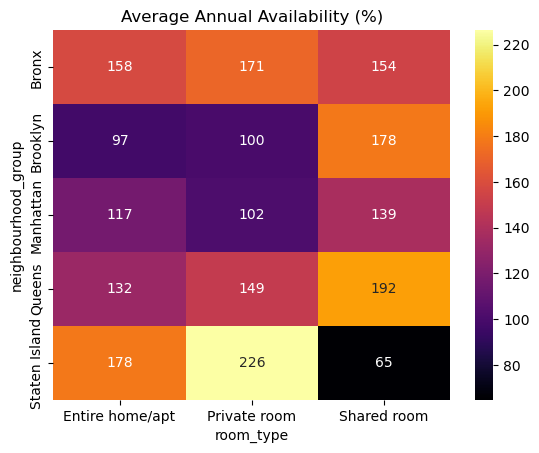

In [40]:
# Pivot for calendar heatmap
availability_pivot = df.pivot_table(
    index='neighbourhood_group',
    columns='room_type',
    values='availability_365',
    aggfunc='mean'
)

sns.heatmap(availability_pivot, cmap='inferno', annot=True, fmt=".0f")
plt.title('Average Annual Availability (%)')

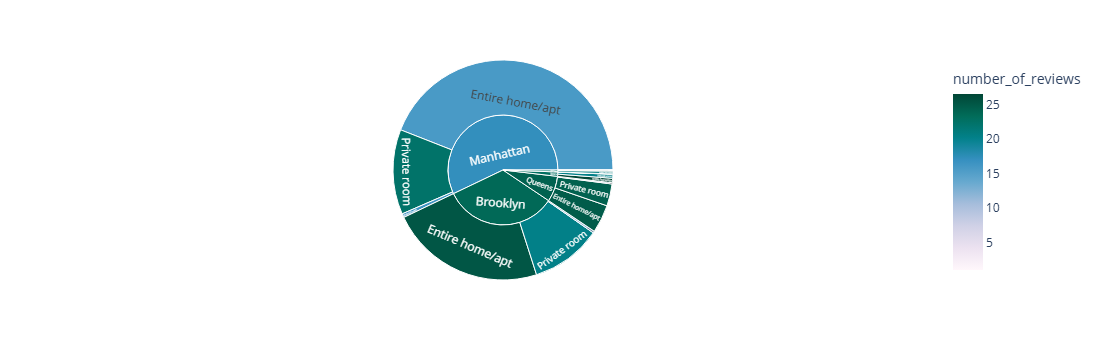

In [47]:
 #sunburst chart
fig = px.sunburst(
    df_cleaned,
    path=['neighbourhood_group', 'room_type'],
    values='price',
    color='number_of_reviews',
    color_continuous_scale='PuBuGn'
)
fig.show()